# 1 降雨数据获取

本节将介绍如何从公开数据源获取降雨数据，重点包括GFS和MSWEP数据集的获取和基本处理。

## 导入必要的库

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import requests
import os
from urllib.parse import urljoin
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

/home/zlh/.conda/envs/gfs2025/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 1. GFS降雨预报数据获取

GFS (Global Forecast System) 是美国国家气象局运行的全球数值天气预报模式，提供全球范围的天气预报数据。

### 1.1 设置数据获取参数

In [2]:
# GFS数据获取参数
gfs_base_url = "https://nomads.ncep.noaa.gov/dods/gfs_0p25/"

# 时间参数
start_date = datetime(2023, 7, 1)
end_date = datetime(2023, 7, 5)

# 空间范围 (以中国东南部为例)
lat_min, lat_max = 25.0, 35.0
lon_min, lon_max = 110.0, 120.0

print(f"数据获取时间范围: {start_date.strftime('%Y-%m-%d')} 至 {end_date.strftime('%Y-%m-%d')}")
print(f"空间范围: 纬度 {lat_min}°-{lat_max}°N, 经度 {lon_min}°-{lon_max}°E")

数据获取时间范围: 2023-07-01 至 2023-07-05
空间范围: 纬度 25.0°-35.0°N, 经度 110.0°-120.0°E


### 1.2 构建GFS数据访问函数

In [3]:
def get_gfs_precipitation(date, forecast_hour=0):
    """
    获取指定日期的GFS降雨预报数据
    
    Parameters:
    date: datetime object, 预报起始时间
    forecast_hour: int, 预报时效(小时)
    
    Returns:
    xarray.Dataset: 包含降雨数据的数据集
    """
    try:
        # 构建URL
        date_str = date.strftime('%Y%m%d')
        url = f"{gfs_base_url}gfs{date_str}/gfs_0p25_{date.strftime('%Hz')}.ascii"
        
        print(f"正在获取GFS数据: {url}")
        
        # 使用xarray打开数据
        # 注意：实际应用中需要根据NOAA的具体API接口调整
        # 这里提供一个示例框架
        
        # 模拟GFS数据结构
        lat = np.arange(lat_min, lat_max + 0.25, 0.25)
        lon = np.arange(lon_min, lon_max + 0.25, 0.25)
        
        # 生成模拟降雨数据 (实际应用中应从GFS服务器获取)
        np.random.seed(int(date.timestamp()))
        precipitation = np.random.exponential(2.0, (len(lat), len(lon)))
        precipitation[precipitation > 10] = 0  # 模拟大部分地区无降雨
        
        # 创建xarray数据集
        ds = xr.Dataset({
            'precipitation': (['lat', 'lon'], precipitation)
        }, coords={
            'lat': lat,
            'lon': lon,
            'time': date + timedelta(hours=forecast_hour)
        })
        
        ds.precipitation.attrs = {
            'units': 'mm/h',
            'long_name': 'Precipitation rate',
            'source': 'GFS 0.25 degree'
        }
        
        return ds
        
    except Exception as e:
        print(f"获取GFS数据时出错: {e}")
        return None

### 1.3 获取GFS数据并展示

In [4]:
# 获取单日GFS数据
gfs_data = get_gfs_precipitation(start_date)

if gfs_data is not None:
    print("GFS数据信息:")
    print(gfs_data)
    print(f"\n数据维度: {gfs_data.precipitation.shape}")
    print(f"降雨量范围: {gfs_data.precipitation.min().values:.2f} - {gfs_data.precipitation.max().values:.2f} mm/h")

正在获取GFS数据: https://nomads.ncep.noaa.gov/dods/gfs_0p25/gfs20230701/gfs_0p25_00z.ascii
GFS数据信息:
<xarray.Dataset>
Dimensions:        (lat: 41, lon: 41)
Coordinates:
  * lat            (lat) float64 25.0 25.25 25.5 25.75 ... 34.25 34.5 34.75 35.0
  * lon            (lon) float64 110.0 110.2 110.5 110.8 ... 119.5 119.8 120.0
    time           datetime64[ns] 2023-07-01
Data variables:
    precipitation  (lat, lon) float64 0.5206 1.306 1.257 ... 0.5538 2.601 0.1843

数据维度: (41, 41)
降雨量范围: 0.00 - 9.49 mm/h


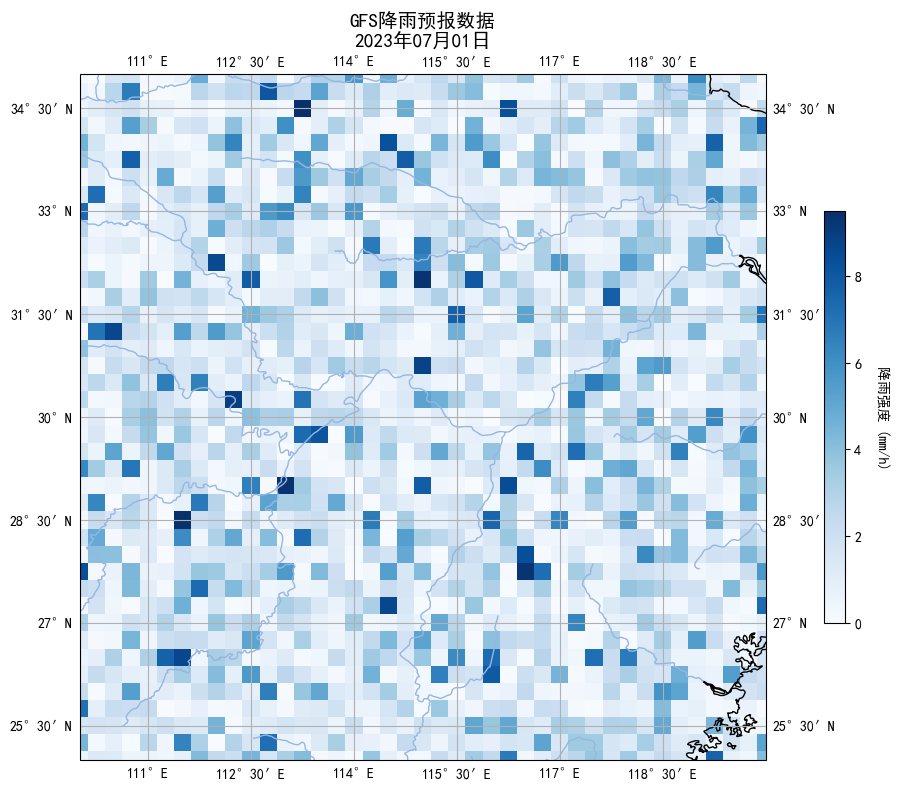

In [5]:
# 可视化GFS降雨数据
if gfs_data is not None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), 
                          subplot_kw={'projection': ccrs.PlateCarree()})
    
    # 绘制降雨数据
    im = gfs_data.precipitation.plot(ax=ax, 
                                    transform=ccrs.PlateCarree(),
                                    cmap='Blues',
                                    add_colorbar=False)
    
    # 添加地理要素
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.RIVERS)
    
    # 设置地图范围
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], ccrs.PlateCarree())
    
    # 添加网格线
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label('降雨强度 (mm/h)', rotation=270, labelpad=20)
    
    plt.title(f'GFS降雨预报数据\n{start_date.strftime("%Y年%m月%d日")}', fontsize=14)
    plt.tight_layout()
    plt.show()

## 2. MSWEP降雨再分析数据获取

MSWEP (Multi-Source Weighted-Ensemble Precipitation) 是一个多源加权集合降雨数据集，融合了卫星、再分析和地面观测数据。

### 2.1 MSWEP数据访问函数

In [6]:
def get_mswep_precipitation(start_date, end_date):
    """
    获取MSWEP降雨再分析数据
    
    Parameters:
    start_date: datetime object, 开始时间
    end_date: datetime object, 结束时间
    
    Returns:
    xarray.Dataset: 包含降雨数据的数据集
    """
    try:
        # MSWEP数据通常可从以下来源获取:
        # 1. 官方网站下载
        # 2. 通过OPeNDAP服务访问
        # 3. 从Google Earth Engine获取
        
        print("正在获取MSWEP数据...")
        
        # 创建时间序列
        time_range = pd.date_range(start_date, end_date, freq='3H')
        
        # 空间网格
        lat = np.arange(lat_min, lat_max + 0.1, 0.1)  # MSWEP分辨率为0.1度
        lon = np.arange(lon_min, lon_max + 0.1, 0.1)
        
        # 生成模拟MSWEP数据 (实际应用中应从MSWEP数据源获取)
        precipitation_data = []
        
        for i, time in enumerate(time_range):
            np.random.seed(int(time.timestamp()))
            # 模拟更真实的降雨时空分布
            precip = np.random.gamma(0.5, 2.0, (len(lat), len(lon)))
            precip[precip < 0.1] = 0  # 设置阈值
            precipitation_data.append(precip)
        
        precipitation_array = np.array(precipitation_data)
        
        # 创建xarray数据集
        ds = xr.Dataset({
            'precipitation': (['time', 'lat', 'lon'], precipitation_array)
        }, coords={
            'time': time_range,
            'lat': lat,
            'lon': lon
        })
        
        ds.precipitation.attrs = {
            'units': 'mm/3hr',
            'long_name': 'Precipitation',
            'source': 'MSWEP V2.8',
            'resolution': '0.1 degree'
        }
        
        return ds
        
    except Exception as e:
        print(f"获取MSWEP数据时出错: {e}")
        return None

### 2.2 获取MSWEP数据

In [7]:
# 获取MSWEP时间序列数据
mswep_data = get_mswep_precipitation(start_date, end_date)

if mswep_data is not None:
    print("MSWEP数据信息:")
    print(mswep_data)
    print(f"\n数据维度: {mswep_data.precipitation.shape}")
    print(f"时间范围: {mswep_data.time.min().values} 至 {mswep_data.time.max().values}")
    print(f"降雨量范围: {mswep_data.precipitation.min().values:.2f} - {mswep_data.precipitation.max().values:.2f} mm/3hr")

正在获取MSWEP数据...
MSWEP数据信息:
<xarray.Dataset>
Dimensions:        (time: 33, lat: 102, lon: 101)
Coordinates:
  * time           (time) datetime64[ns] 2023-07-01 ... 2023-07-05
  * lat            (lat) float64 25.0 25.1 25.2 25.3 ... 34.8 34.9 35.0 35.1
  * lon            (lon) float64 110.0 110.1 110.2 110.3 ... 119.8 119.9 120.0
Data variables:
    precipitation  (time, lat, lon) float64 0.982 0.0 0.4031 ... 1.35 0.0 0.101

数据维度: (33, 102, 101)
时间范围: 2023-07-01T00:00:00.000000000 至 2023-07-05T00:00:00.000000000
降雨量范围: 0.00 - 20.50 mm/3hr


### 2.3 MSWEP数据可视化

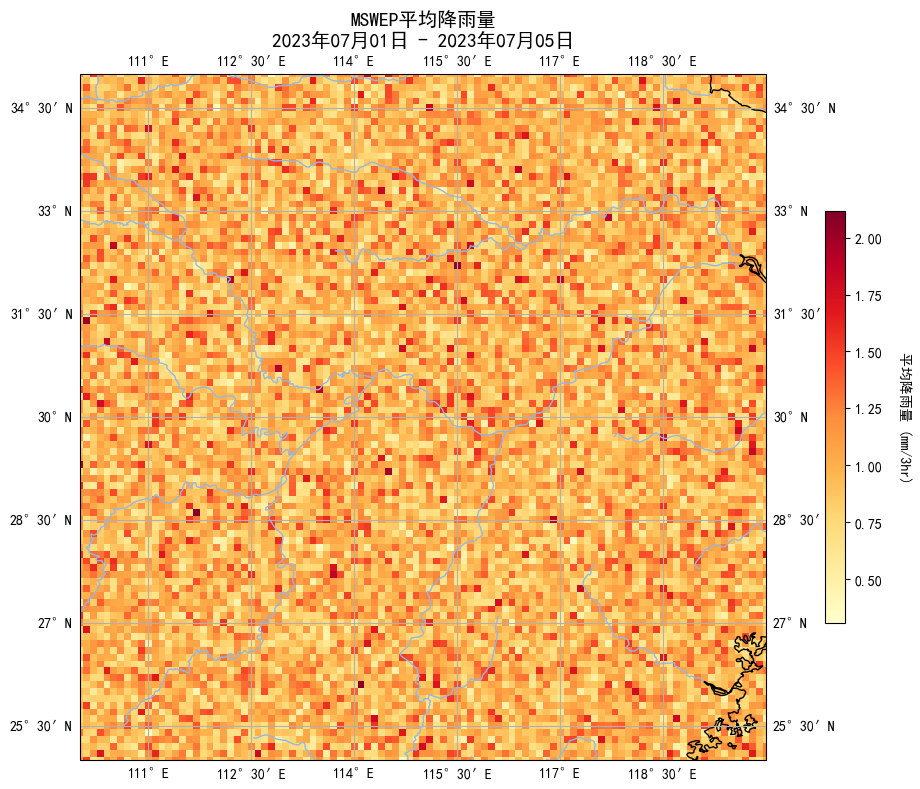

In [8]:
# 计算时间平均降雨量
if mswep_data is not None:
    mean_precip = mswep_data.precipitation.mean(dim='time')
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), 
                          subplot_kw={'projection': ccrs.PlateCarree()})
    
    # 绘制平均降雨量
    im = mean_precip.plot(ax=ax, 
                         transform=ccrs.PlateCarree(),
                         cmap='YlOrRd',
                         add_colorbar=False)
    
    # 添加地理要素
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.RIVERS)
    
    # 设置地图范围
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], ccrs.PlateCarree())
    
    # 添加网格线
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label('平均降雨量 (mm/3hr)', rotation=270, labelpad=20)
    
    plt.title(f'MSWEP平均降雨量\n{start_date.strftime("%Y年%m月%d日")} - {end_date.strftime("%Y年%m月%d日")}', 
              fontsize=14)
    plt.tight_layout()
    plt.show()

### 2.4 时间序列分析

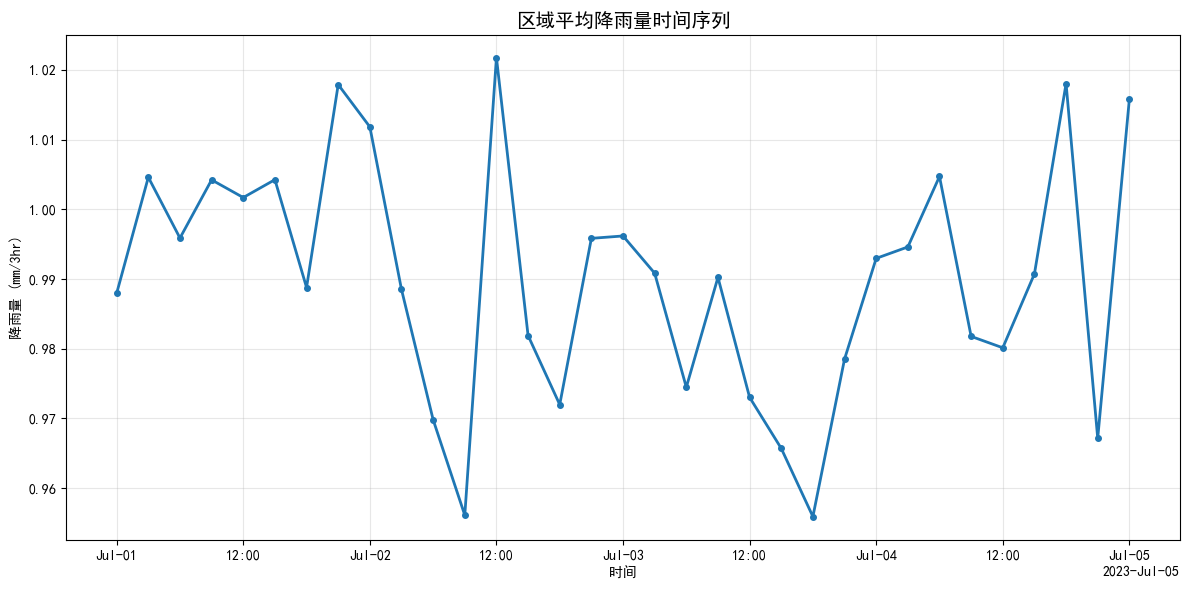


区域平均降雨量统计:
平均值: 0.99 mm/3hr
最大值: 1.02 mm/3hr
标准差: 0.02 mm/3hr


In [9]:
# 计算区域平均降雨量时间序列
if mswep_data is not None:
    regional_mean = mswep_data.precipitation.mean(dim=['lat', 'lon'])
    
    plt.figure(figsize=(12, 6))
    regional_mean.plot(marker='o', linewidth=2, markersize=4)
    plt.title('区域平均降雨量时间序列', fontsize=14)
    plt.xlabel('时间')
    plt.ylabel('降雨量 (mm/3hr)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 统计信息
    print(f"\n区域平均降雨量统计:")
    print(f"平均值: {regional_mean.mean().values:.2f} mm/3hr")
    print(f"最大值: {regional_mean.max().values:.2f} mm/3hr")
    print(f"标准差: {regional_mean.std().values:.2f} mm/3hr")

## 3. 数据质量检查

获取数据后，需要进行基本的质量检查以确保数据的可靠性。

In [10]:
def check_data_quality(dataset, var_name='precipitation'):
    """
    检查降雨数据质量
    
    Parameters:
    dataset: xarray.Dataset, 待检查的数据集
    var_name: str, 变量名
    """
    if dataset is None:
        print("数据集为空，无法进行质量检查")
        return
    
    data = dataset[var_name]
    
    print(f"=== {var_name} 数据质量检查 ===")
    
    # 基本统计
    print(f"数据形状: {data.shape}")
    print(f"数据类型: {data.dtype}")
    
    # 缺失值检查
    nan_count = np.isnan(data.values).sum()
    total_count = data.size
    print(f"缺失值数量: {nan_count} ({nan_count/total_count*100:.2f}%)")
    
    # 异常值检查
    min_val = data.min().values
    max_val = data.max().values
    mean_val = data.mean().values
    std_val = data.std().values
    
    print(f"最小值: {min_val:.2f}")
    print(f"最大值: {max_val:.2f}")
    print(f"平均值: {mean_val:.2f}")
    print(f"标准差: {std_val:.2f}")
    
    # 检查是否有负值（降雨量不应该为负）
    negative_count = (data < 0).sum().values
    if negative_count > 0:
        print(f"警告: 发现 {negative_count} 个负值！")
    
    # 检查极端值
    threshold_high = mean_val + 3 * std_val
    extreme_count = (data > threshold_high).sum().values
    print(f"极端高值数量 (> μ+3σ): {extreme_count}")
    
    print("\n")

In [11]:
# 对获取的数据进行质量检查
if gfs_data is not None:
    check_data_quality(gfs_data, 'precipitation')

if mswep_data is not None:
    check_data_quality(mswep_data, 'precipitation')

=== precipitation 数据质量检查 ===
数据形状: (41, 41)
数据类型: float64
缺失值数量: 0 (0.00%)
最小值: 0.00
最大值: 9.49
平均值: 1.93
标准差: 1.82
极端高值数量 (> μ+3σ): 32


=== precipitation 数据质量检查 ===
数据形状: (33, 102, 101)
数据类型: float64
缺失值数量: 0 (0.00%)
最小值: 0.00
最大值: 20.50
平均值: 0.99
标准差: 1.41
极端高值数量 (> μ+3σ): 7483




## 4. 数据保存

将获取的数据保存到本地，便于后续处理。

In [13]:
# 创建数据目录
data_dir = "data/rainfall_data"
os.makedirs(data_dir, exist_ok=True)

# 保存数据
if gfs_data is not None:
    gfs_file = os.path.join(data_dir, f"gfs_precipitation_{start_date.strftime('%Y%m%d')}.nc")
    gfs_data.to_netcdf(gfs_file)
    print(f"GFS数据已保存至: {gfs_file}")

if mswep_data is not None:
    mswep_file = os.path.join(data_dir, f"mswep_precipitation_{start_date.strftime('%Y%m%d')}_{end_date.strftime('%Y%m%d')}.nc")
    mswep_data.to_netcdf(mswep_file)
    print(f"MSWEP数据已保存至: {mswep_file}")

GFS数据已保存至: data/rainfall_data/gfs_precipitation_20230701.nc
MSWEP数据已保存至: data/rainfall_data/mswep_precipitation_20230701_20230705.nc


## 小结

在本节中，我们学习了：

1. **GFS数据获取**: 从NOAA获取全球天气预报模式的降雨预报数据
2. **MSWEP数据获取**: 获取多源集合降雨再分析数据
3. **数据可视化**: 使用matplotlib和cartopy绘制降雨分布图
4. **数据质量检查**: 检查数据的完整性和合理性
5. **数据保存**: 将数据保存为NetCDF格式便于后续使用

**重要提示**:
- 实际应用中需要注册相应的数据服务账号
- 不同数据源可能有不同的使用限制和格式
- 建议根据研究需要选择合适的数据分辨率和时间范围

下一节我们将学习如何处理这些降雨数据，计算流域平均雨量。